## Bank Marketing
* Abstract: The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).

* Data Set Information: The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed.

In [44]:
# importing the libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [45]:
# reading the dataset

bank_df = pd.read_csv('./bank.csv')

In [46]:
bank_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [47]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [48]:
round(bank_df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.23,11.91,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.54,3225.41,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.66,8.42,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.99,347.13,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.51,2.72,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.33,108.76,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.83,2.29,0.0,0.0,0.0,1.00,58.0


In [49]:
# checking for null values
bank_df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

* no null values

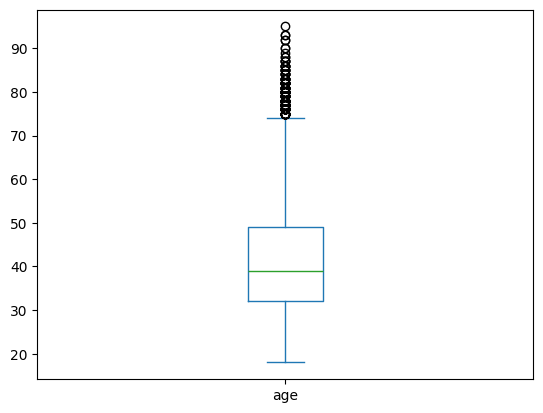

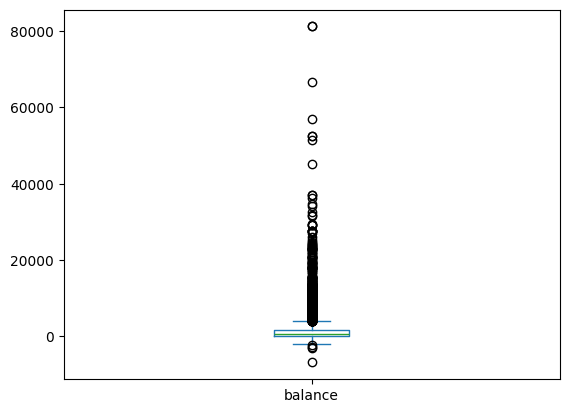

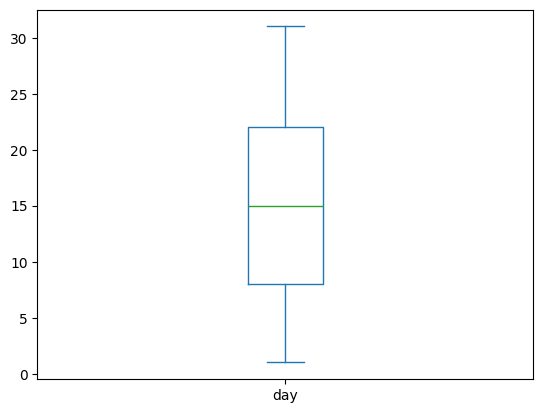

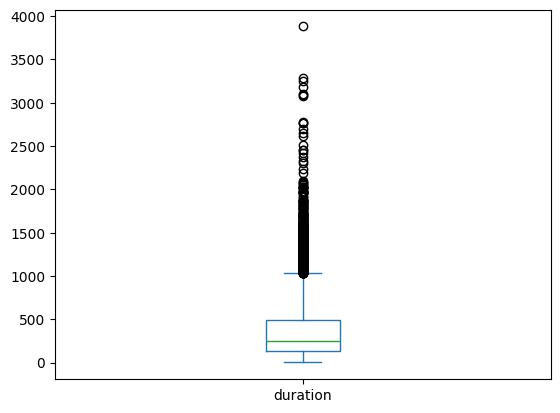

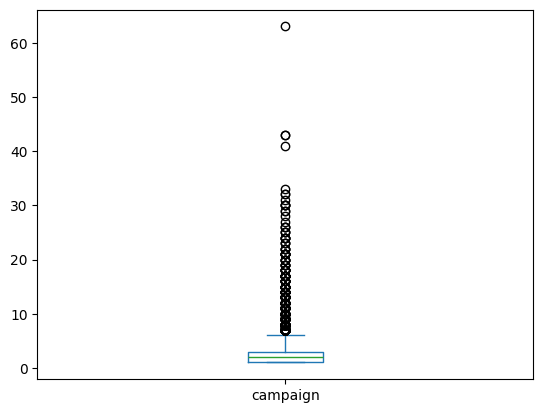

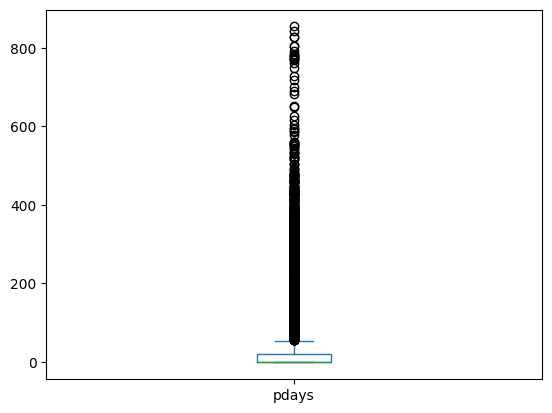

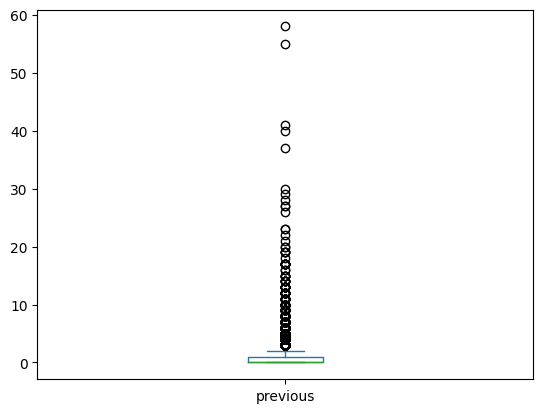

In [50]:
def plot(cols) :
    bank_df[[cols]].plot(kind = 'box')

numeric_cols = bank_df.select_dtypes(include = np.number).columns.tolist()
for cols in numeric_cols :
    plot(cols)

* OBSERVATION : many numeric columns have outliers

In [51]:
categorical_cols = bank_df.select_dtypes(include = 'object').columns.tolist()

for cols in categorical_cols:
    unique = bank_df[cols].unique()
    print(f"Column : {cols}")
    print(f"Unique Value : {unique}")
    print("\n")

Column : job
Unique Value : ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']


Column : marital
Unique Value : ['married' 'single' 'divorced']


Column : education
Unique Value : ['secondary' 'tertiary' 'primary' 'unknown']


Column : default
Unique Value : ['no' 'yes']


Column : housing
Unique Value : ['yes' 'no']


Column : loan
Unique Value : ['no' 'yes']


Column : contact
Unique Value : ['unknown' 'cellular' 'telephone']


Column : month
Unique Value : ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']


Column : poutcome
Unique Value : ['unknown' 'other' 'failure' 'success']


Column : deposit
Unique Value : ['yes' 'no']




* DROPPING THE COLUMNS THAT ARE NOT NEEDED

In [52]:
bank_df.drop('default',inplace=True,axis=1)

* FINDING THE COLUMNS WITH THE VALUES 'YES' AND 'NO'

In [53]:
categorical_cols = bank_df.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
        unique_val = bank_df[col].dropna().unique()
        
        if set(unique_val).issubset({'yes', 'no'}):
            print(f"Column: {col}")
            print(f"Values: {unique_val}")

Column: housing
Values: ['yes' 'no']
Column: loan
Values: ['no' 'yes']
Column: deposit
Values: ['yes' 'no']


In [54]:
mapping_cols = ['housing','loan','deposit']
mapping_code = {'yes' : 1,'no' : 0}

def mapping(cols) :
    for col in cols:
        bank_df[col] = bank_df[col].map(mapping_code)

mapping(mapping_cols)

In [55]:
# checking the columns
bank_df[mapping_cols]

,housing,loan,deposit
0,1,0,1
1,0,0,1
2,1,0,1
3,1,0,1
4,0,0,1
...,...,...,...
11157,1,0,0
11158,0,0,0
11159,0,0,0
11160,0,1,0


* it is for the best if the rest of the categorical columns be encoded

In [59]:
bank_df[categorical_cols].columns.tolist()

['job',
 'marital',
 'education',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'deposit']

* OBSERVATION : WE DO HAVE UNKNOWN VALUES IN C_COLS. HOWEVER IT WOULD NOT BE WISE TO REMOVE THOSE ROWS WHICH HAVE UNKNONW VALUES. SO IT IS BETTER TO ENCODE THEM AS WELL

* BUT FIRST DIVIDE THE DATA INTO X AND Y AND THEN ENCODED IT

In [61]:
X = bank_df.drop('deposit', axis = 1)
y = bank_df['deposit']

print(X.shape)
print(y.shape)

(11162, 15)
(11162,)


In [63]:
c_cols = ['job',
 'marital',
 'education',
 'contact',
 'month',
 'poutcome',
]

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X[c_cols])

encoded = list(encoder.get_feature_names_out(c_cols))
X[encoded] = encoder.transform(X[c_cols])

# droping the c_cols
X.drop(columns = c_cols,inplace = True)

In [80]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score
from sklearn.pipeline import Pipeline

In [81]:
def train_model(model, name, X, y, scale=True):
    if scale:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model',  model)
        ])
    else:
        pipe = Pipeline([
            ('model', model)
        ])

    skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='f1_macro')
    y_pred = cross_val_predict(pipe, X, y, cv=skf)


    print(f"{name} model")
    print(f"F1 per fold : {scores.round(3)}")
    print(f"Average F1  : {scores.mean():.3f}")
    print(f"Accuracy {accuracy_score(y,y_pred):.3f}")

    ConfusionMatrixDisplay.from_predictions(y, y_pred)
    plt.title(f"{name} — Confusion Matrix (K-Fold)")
    plt.show()

# 1. THE BASELINE MODEL

Logistic Regression model
F1 per fold : [0.817 0.835 0.829 0.824 0.818]
Average F1  : 0.824
Accuracy 0.825


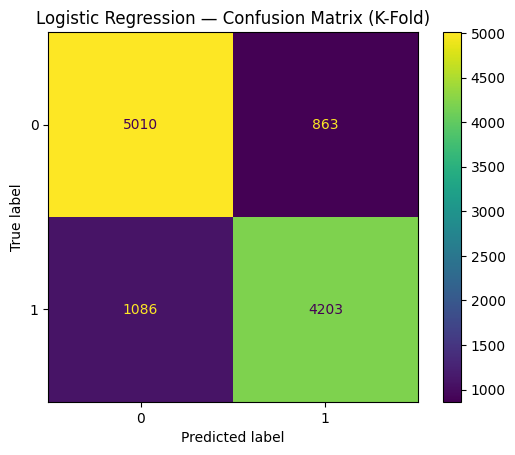

In [82]:
lr_model = LogisticRegression(random_state=42)


train_model(lr_model, 'Logistic Regression', X, y, scale=True)  # scales

# 2. RANDOM FOREST

Random Forest model
F1 per fold : [0.827 0.832 0.84  0.83  0.843]
Average F1  : 0.834
Accuracy 0.835


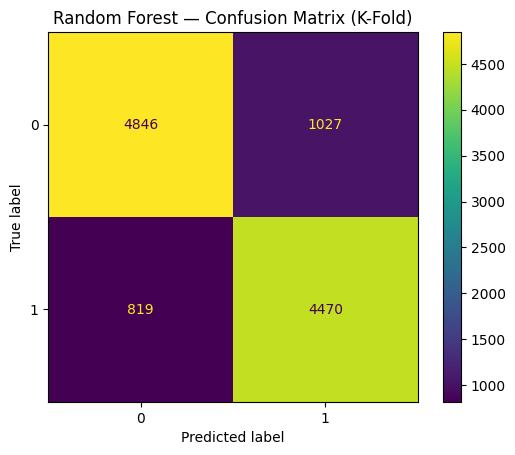

In [83]:
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                  max_depth=7, random_state=42)

train_model(rf_model, 'Random Forest',X, y, scale=False)  # skips scaling

* OBSERVATION : HIGHER F1 SCORE MEAND THE MODEL IS DOING WELL (mostly on the positive class)  AND ACCURACY IS HIGHER THAN 80%